In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sklearn
import pmdarima
from sktime.forecasting.arima import AutoARIMA, ARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_correlations
from sktime.performance_metrics.forecasting import mean_absolute_scaled_error,mean_absolute_percentage_error

In [2]:
data = pd.read_csv('parkingLot.csv')
# data = data.dropna()
print(data.shape)

data.head()

(106694, 3)


,vehicle_no,timestamp,camera_id
0,MHUN7063,2024-09-12 05:00:00,1
1,MHYN4677,2024-09-12 05:00:00,1
2,MHEL6595,2024-09-12 05:00:00,1
3,MHNQ2590,2024-09-12 05:00:00,1
4,MHHA0518,2024-09-12 05:00:00,1


In [3]:
entry_data = data[data['camera_id'] == 1]
print(entry_data.shape)

(53347, 3)


In [4]:
# Convert the 'timestamp' column to datetime
entry_data['timestamp'] = pd.to_datetime(entry_data['timestamp'])
print(entry_data.shape)

# Extract the date part from the timestamp and group by the date to count the number of vehicles
cars_per_date = entry_data.groupby(entry_data['timestamp'].dt.date).size().reset_index(name='number_of_cars_entering')

# Identify outliers using the IQR method
Q1 = cars_per_date['number_of_cars_entering'].quantile(0.25)
Q3 = cars_per_date['number_of_cars_entering'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# Replace outliers with NaN
cars_per_date.loc[cars_per_date['number_of_cars_entering'] < lower_bound, 'number_of_cars_entering'] = None
cars_per_date.loc[cars_per_date['number_of_cars_entering'] > upper_bound, 'number_of_cars_entering'] = None

# Perform linear interpolation on 'number_of_cars_entering'
cars_per_date['number_of_cars_entering'] = cars_per_date['number_of_cars_entering'].interpolate(method='linear')

# Print the updated DataFrame after replacing outliers and interpolating
print(cars_per_date)


(53347, 3)
     timestamp  number_of_cars_entering
0   2024-09-12                    886.0
1   2024-09-13                    809.0
2   2024-09-14                    925.0
3   2024-09-15                    884.0
4   2024-09-16                    843.0
..         ...                      ...
58  2024-11-09                    906.0
59  2024-11-10                    944.0
60  2024-11-11                    828.0
61  2024-11-12                    806.0
62  2024-11-13                    781.0

[63 rows x 2 columns]


/tmp/ipykernel_1405/854978071.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entry_data['timestamp'] = pd.to_datetime(entry_data['timestamp'])


<Axes: xlabel='timestamp', ylabel='number_of_cars_entering'>

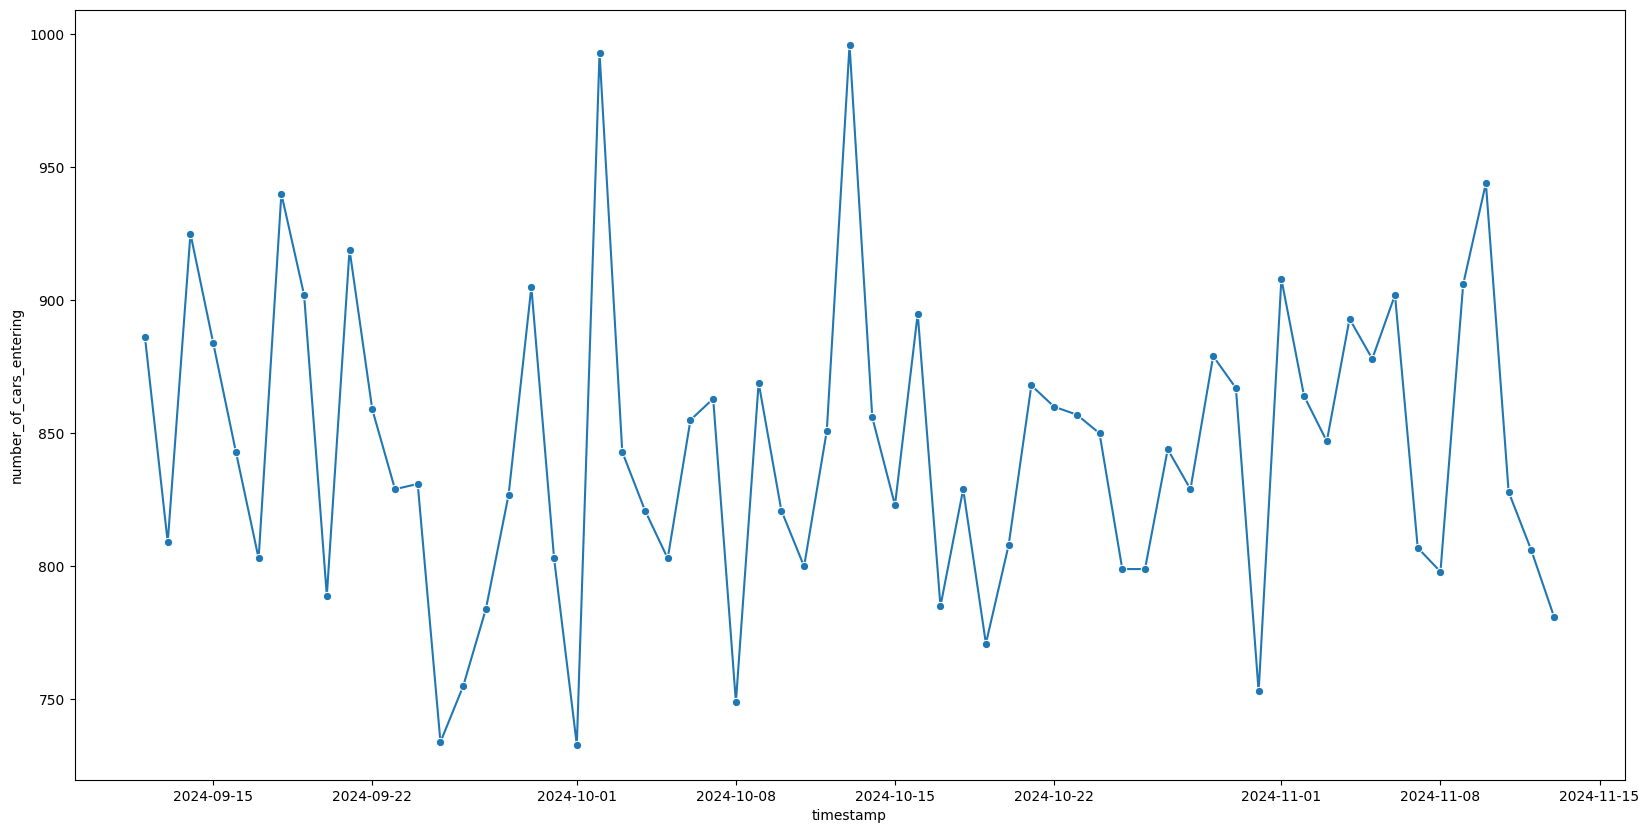

In [5]:
#plotting cars per date
plt.figure(figsize=(20, 10))
sns.lineplot(x='timestamp', y='number_of_cars_entering', data=cars_per_date, marker='o')

In [6]:
# Splitting the data into training and testing sets
train_data = cars_per_date.iloc[:56]
test_data = cars_per_date.iloc[56:]

print("Training Data:")
print(train_data)
print("\nTesting Data:")
print(test_data)

Training Data:
     timestamp  number_of_cars_entering
0   2024-09-12                    886.0
1   2024-09-13                    809.0
2   2024-09-14                    925.0
3   2024-09-15                    884.0
4   2024-09-16                    843.0
5   2024-09-17                    803.0
6   2024-09-18                    940.0
7   2024-09-19                    902.0
8   2024-09-20                    789.0
9   2024-09-21                    919.0
10  2024-09-22                    859.0
11  2024-09-23                    829.0
12  2024-09-24                    831.0
13  2024-09-25                    734.0
14  2024-09-26                    755.0
15  2024-09-27                    784.0
16  2024-09-28                    827.0
17  2024-09-29                    905.0
18  2024-09-30                    803.0
19  2024-10-01                    733.0
20  2024-10-02                    993.0
21  2024-10-03                    843.0
22  2024-10-04                    821.0
23  2024-10-05           

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='number_of_cars_entering'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

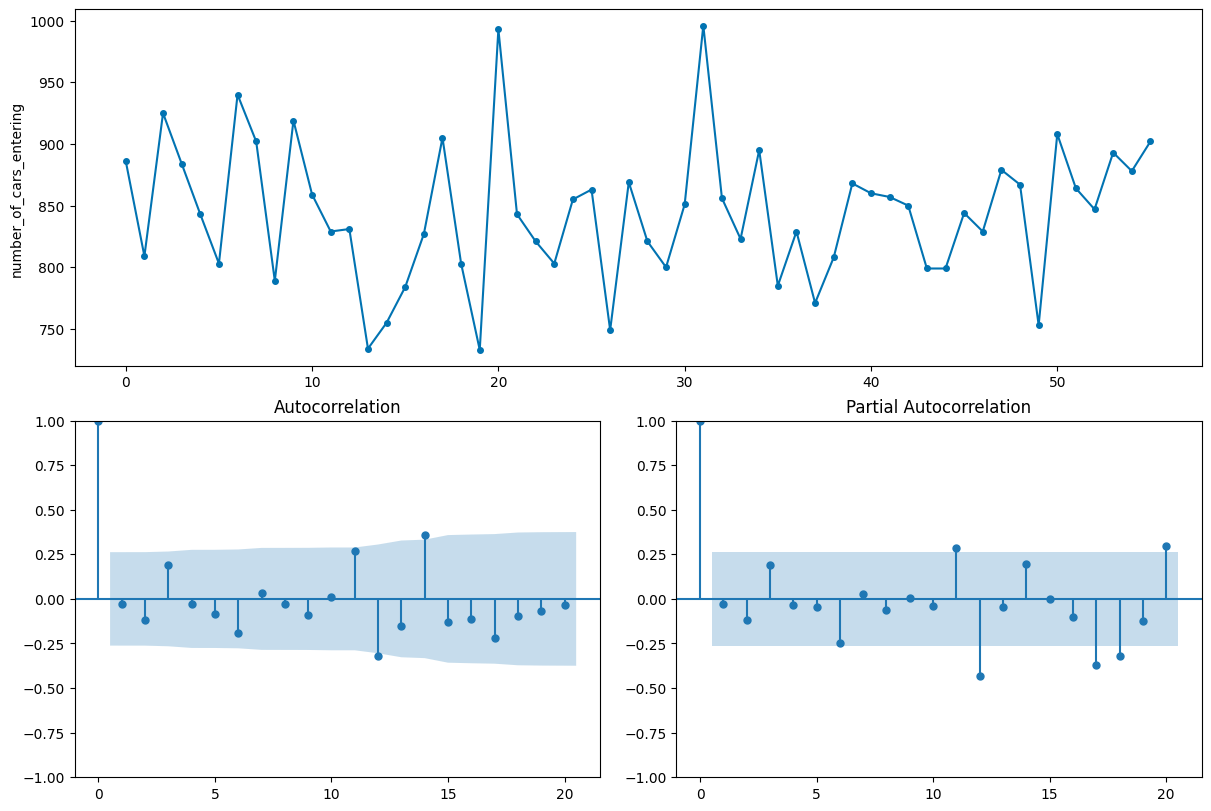

In [7]:
plot_correlations(train_data['number_of_cars_entering'], lags=20)

In [8]:
forecaster = ARIMA(order=(3, 0, 3), seasonal_order=(0, 1, 1, 14),suppress_warnings=True)
# forecaster = AutoARIMA(,suppress_warnings=True)

forecaster.fit(train_data['number_of_cars_entering'])
forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                   56
Model:             SARIMAX(3, 0, 3)x(0, 1, [1], 14)   Log Likelihood                -230.523
Date:                              Mon, 28 Oct 2024   AIC                            479.047
Time:                                      21:23:48   BIC                            494.686
Sample:                                           0   HQIC                           484.779
                                               - 56                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.0149     15.327      0.066      0.947     -29.026      31.055
ar.L1          0.0776      0.285      0.272      0.785      -0.480       0.636
ar.L2         -0.1705      0.300     -0.568      0.570      -0.759       0.418
ar.L3         -0.5043      0.296     -1.706      0.088      -1.084       0.075
ma.L1          0.0632     34.933      0.002      0.999     -68.404      68.531
ma.L2          0.0639     36.849      0.002      0.999     -72.159      72.286
ma.L3          0.9993     58.972      0.017      0.986    -114.583     116.582
ma.S.L14      -0.3836      0.324     -1.185      0.236      -1.018       0.251
sigma2      2948.7184   1.74e+05      0.017      0.986   -3.37e+05    3.43e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 0.72
Prob(Q):                              0.78   Prob(JB):                         0.70
Heteroskedasticity (H):               0.58   Skew:                            -0.14
Prob(H) (two-sided):                  0.32   Kurtosis:                         2.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

56    846.0
57    792.0
58    814.0
59    885.0
60    839.0
61    854.0
62    892.0
Name: number_of_cars_entering, dtype: float64


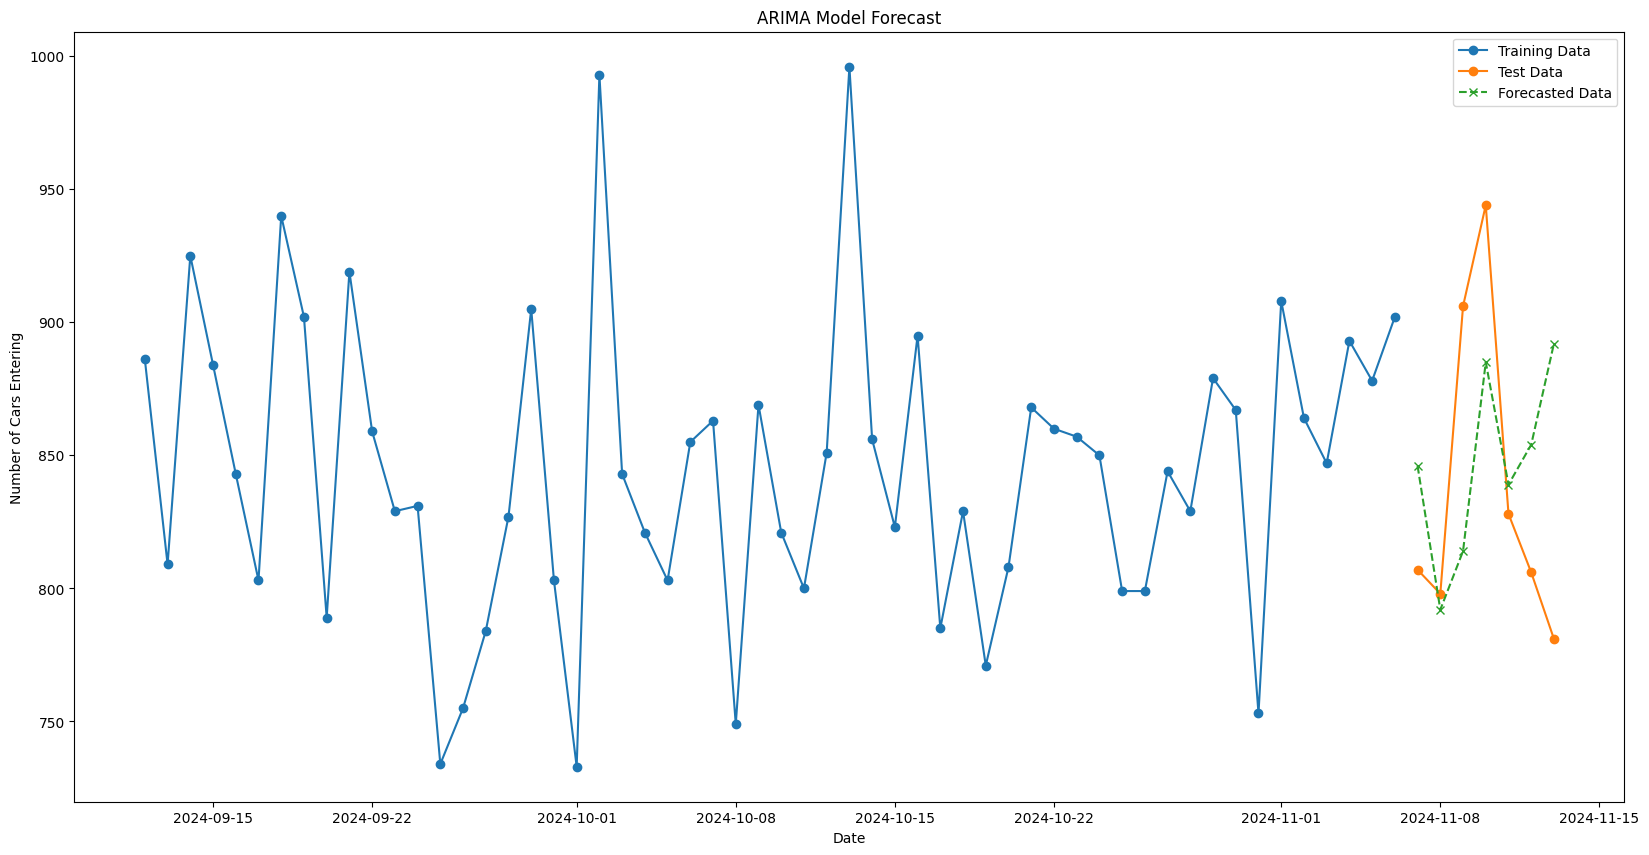

In [9]:
# Forecasting the test data

forecast = np.round(forecaster.predict(fh=[1, 2 ,3 , 4, 5, 6, 7]))

# print(test_data.shape[0])
print(forecast)

# print(test_data['number_of_cars_entering'])

# Plotting the training data, test data, and forecasted data
plt.figure(figsize=(20, 10))
plt.plot(train_data['timestamp'], train_data['number_of_cars_entering'], label='Training Data', marker = 'o')
plt.plot(test_data['timestamp'], test_data['number_of_cars_entering'], label='Test Data',marker = 'o')
plt.plot(test_data['timestamp'], forecast, label='Forecasted Data', linestyle='--',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

In [10]:
# Calculating the error metrics
MASE = mean_absolute_scaled_error(y_train=train_data['number_of_cars_entering'],y_true=test_data['number_of_cars_entering'], y_pred=forecast)
MAPE = mean_absolute_percentage_error(test_data['number_of_cars_entering'], forecast)

print('Mean Absolute Scaled Error:', MASE)
print('Mean Absolute Percentage Error:', MAPE)

Mean Absolute Scaled Error: 0.8374240785423079
Mean Absolute Percentage Error: 0.06212214894089334


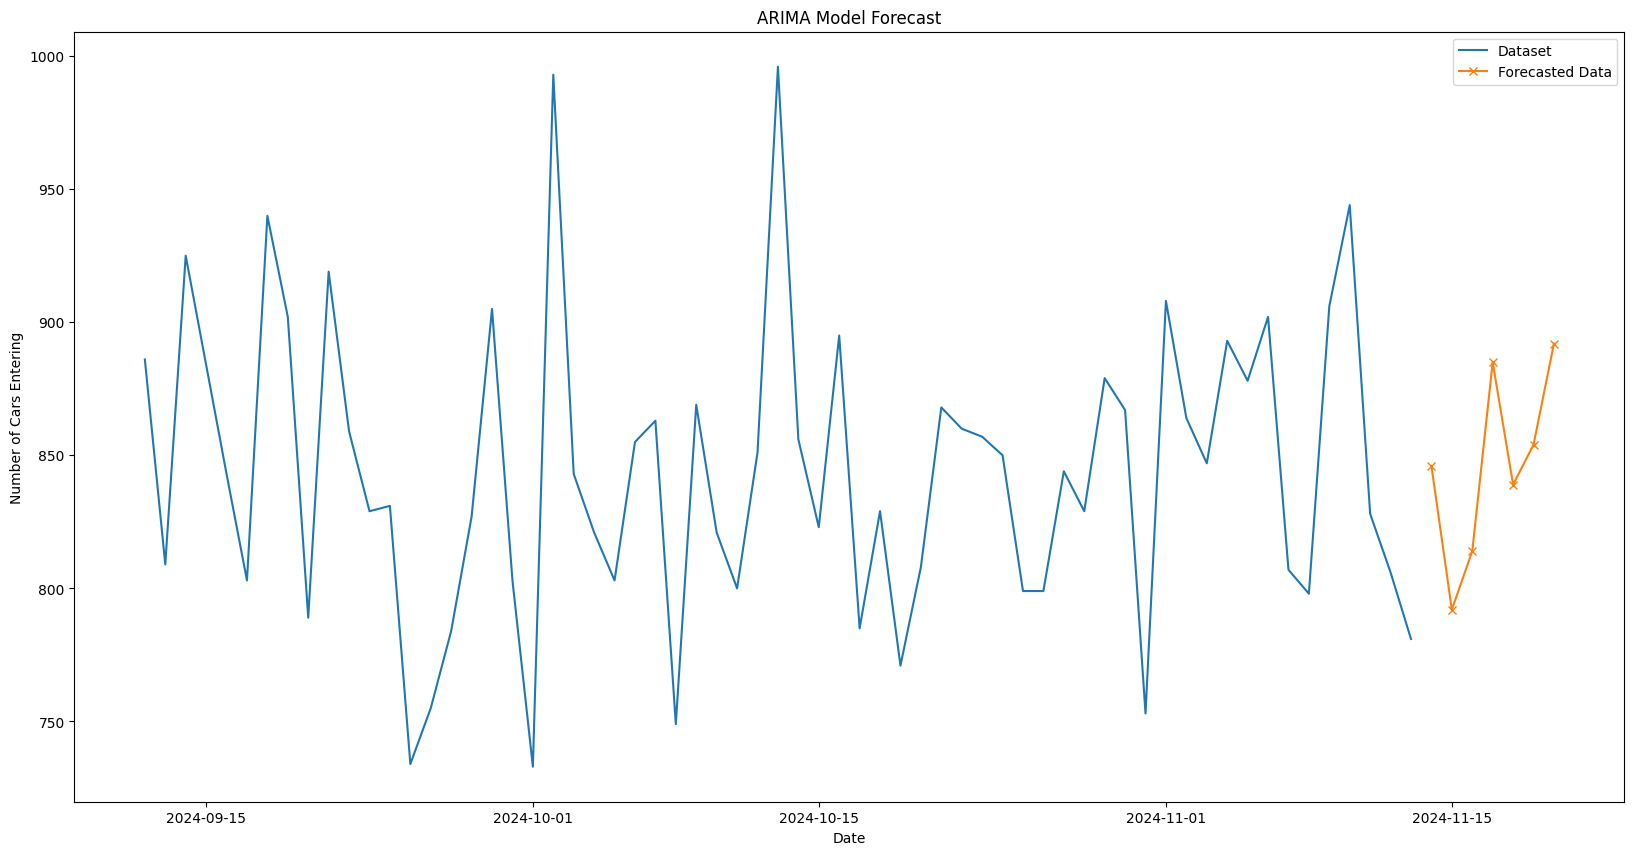

In [11]:
#forecast for the next 7 days
forecast_final = np.floor(forecaster.predict([8,9,10,11,12,13,14]))
# Create dates for the next 7 days after the last entry of cars_per_date
last_date = cars_per_date['timestamp'].iloc[-1]
next_7_days = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

# # Add the forecasted values to the dataframe
# forecast_final_df = pd.DataFrame({'timestamp': next_7_days, 'number_of_cars_entering': forecast_final})
# print(forecast_final_df)
plt.figure(figsize=(20, 10))
plt.plot(cars_per_date['timestamp'], cars_per_date['number_of_cars_entering'], label='Dataset')
plt.plot(next_7_days, forecast, label='Forecasted Data', linestyle='-',marker = 'x')

plt.xlabel('Date')
plt.ylabel('Number of Cars Entering')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()